# Fundamentals of Time Series Econometrics

## Assignment: Modelling US National Electricity Generation

This notebook is a part of the course *"Fundamentals of Time Series Econometrics"* by VU Amsterdam in the minor *"Applied Econometrics: A Big Data Experience for all"*. This notebook contains the assignment for this course and will cover modelling national electricity generation in the US.

### Data
The data describe the US monthly electricity generation from January 1973 to May 2026. More specifically, they pertain to total net generation across all sectors (MSN: ELETPUS). The data come from the U.S. Energy Information Administration ([source](https://www.eia.gov/totalenergy/data/browser/csv.php?tbl=T07.01)).  The series is provided in the `MER_T07_01.csv` file, which can be found in the *Data* module on Canvas.


### Structure
In total, you can get 100 points for the assignment. The assignment consists of five main parts. The parts and the point distribution are specified below.

* Part 1: Preparation (25 pts)
* Part 2: Baseline Model (15 pts)
* Part 3: Model Selection In-Sample (15 pts)
* Part 4: Model Selection Out-of-Sample (20 pts)
* Part 5: Benchmarking (25 pts)

In [1]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.tsa.api as tsa
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
import os
import pandas as pd
import seaborn as sns

drive.mount('/content/drive')

base_dir = '/content/drive/My Drive/code/'
data_dir = base_dir + 'data/'
figs_dir = base_dir + 'figs/'
dpi = 150

os.makedirs(figs_dir, exist_ok=True)

# US national electricity generation
electricity = pd.read_csv(data_dir + 'MER_T07_01.csv', header=0)

Mounted at /content/drive


# PART 1: Preparation (25 pts)

## 1. Load and visualize the US national electricity generation time series

In the cell below you are expected to load the US national electricity generation time series. The data are stored in the file `MER_T07_01.csv`. The file contains multiple columns of which `YYYYMM` and `Value` are important. The `YYYYMM` column contains the date value in a YYYYMM format value (e.g. 200001 for January 2000), and the `Value` column contains the US national electricity generation (in thousand Megawatthours). **Note:** In the csv file there are entries coded as month 13. These are annual totals which you need to exclude.

After loading the data, you should visualize the time series. The time series should be plotted with the dates in the form of years on the x-axis and the  electricity generation series on the y-axis.

Comment on the dynamics of the time series. What do you observe? Do you believe the time series is stationary and why?

In [3]:
electricity.head(25)

,MSN,YYYYMM,Value,Column_Order,Description,Unit
0,ELEGPUS,194913,291.1,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
1,ELEGPUS,195013,329.141,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
2,ELEGPUS,195113,370.673,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
3,ELEGPUS,195213,399.224,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
4,ELEGPUS,195313,442.665,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
5,ELEGPUS,195413,471.686,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
6,ELEGPUS,195513,547.038,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
7,ELEGPUS,195613,600.668,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
8,ELEGPUS,195713,631.517,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
9,ELEGPUS,195813,645.098,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours


In [4]:
print(electricity['MSN'].unique())
print(electricity.index.duplicated().sum())

['ELEGPUS' 'ELC5PUS' 'ELI5PUS' 'ELETPUS' 'ELIMPUS' 'ELEXPUS' 'ELNIPUS'
 'ELUNPUS' 'ESTCPUS' 'ELDUPUS' 'ELTCPUS']
0


In [5]:
electricity_ELETPUS =electricity[electricity["MSN"] == "ELETPUS"].copy()


electricity_ELETPUS = electricity_ELETPUS[electricity_ELETPUS['YYYYMM'] % 100 != 13]
electricity_ELETPUS['date'] = pd.to_datetime(electricity_ELETPUS['YYYYMM'].astype(str), format='%Y%m')
electricity_ELETPUS['Value'] = pd.to_numeric(electricity_ELETPUS['Value'], errors='coerce')
electricity_ELETPUS.set_index('date', inplace=True)

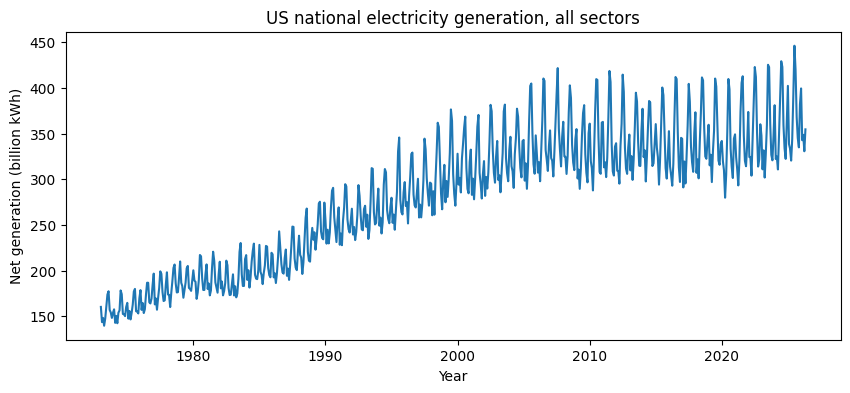

In [6]:
# plot
y= electricity_ELETPUS['Value'].sort_index().dropna()
y=y.asfreq("MS")

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(y.index, y.values)
ax.set_xlabel("Year")
ax.set_ylabel("Net generation (billion kWh)")
ax.set_title("US national electricity generation, all sectors")
plt.show()

The plot shows a clear upward trend: electricity generation in the US grows from about 150 billion kWh in 1973 to about 350 around 2007, followed by a plateau with a slight upward drift at the end. There is also regular yearly seasonality, with summer peaks (likely air conditioning demand), and the seasonal amplitude grows with the level (roughly 140-180 in the 1970s versus 290-420 in the 2010s). Small dips around 2009 and 2020 are likely due to the recession and COVID-19.

A weakly stationary series fluctuates around a fixed level and returns to it after deviations.

Formally:

1. constant mean, E[X_t] = μ;
2. constant variance, Var(X_t) = σ²;
3. autocovariance depends only on the lag h, Cov(X_t, X_{t+h}) = γ(h).

I do not believe the series is stationary. (1) The mean is not constant: it rises over decades (trend) and depends on the month (seasonality). (2) The variance is not constant: seasonal swings are larger in later years. (3) Because the mean changes over time, the autocovariance depends on t and not only on h, and we expect very slowly decaying autocorrelations.

## 2. Autocorrelation and Partial Autocorrelation

To gain a better understanding of the dynamics in US national electricity generation time series you are asked to plot the autocorrelation function (ACF) and partial autocorrelation function (PACF) of the time series in the cell below. You can set the amount of lags equal to 36 (equivalent to 3 years).

What do you observe in the ACF and PACF plots? What data transformations would you apply to the time series? What kind of dynamics are present in the time series?

Do you see any seasonal patterns in the ACF and PACF plots? Is this in line with what you observed in the time series plot? If there is a discrepancy, what does this tell you about the dynamics?

**ACF at lag h:** the correlation between the series today and h months ago.

**PACF at lag h:** the same correlation after removing the effect of the lags in between. It tells what lag h adds beyond lags 1 to h-1.

For a stationary series the ACF dies out quickly. For a trending series, the value today is close to the value last month, and the month before that, and so on, so the ACF stays high for a very long time.

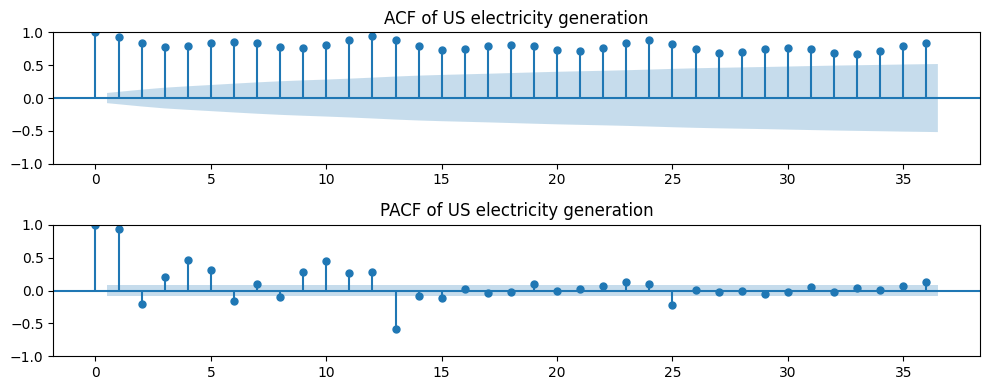

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2,1, figsize=(10,4))
plot_acf(y, lags=36, ax=axes[0])
plot_pacf(y, lags=36, ax=axes[1], method='ywm')
axes[0].set_title("ACF of US electricity generation")
axes[1].set_title("PACF of US electricity generation")
plt.tight_layout()
plt.show()

In [8]:
from statsmodels.tsa.stattools import acf, pacf

acf_vals = acf(y, nlags=36)
pacf_vals = pacf(y, nlags=36, method='ywm')

# confidence band (approx. 95%): +/- 1.96 / sqrt(n)
band = 1.96 / np.sqrt(len(y))

table = pd.DataFrame({'ACF': acf_vals, 'PACF': pacf_vals})
table['PACF significant'] = table['PACF'].abs() > band
print(table.round(3))
print("band:", round(band, 3))

# only the significant PACF lags
print(table[table['PACF significant']].index.tolist())

      ACF   PACF  PACF significant
0   1.000  1.000              True
1   0.931  0.931              True
2   0.839 -0.200              True
3   0.778  0.207              True
4   0.788  0.464              True
5   0.842  0.309              True
6   0.858 -0.166              True
7   0.835  0.104              True
8   0.775 -0.099              True
9   0.757  0.278              True
10  0.810  0.443              True
11  0.888  0.270              True
12  0.942  0.275              True
13  0.879 -0.586              True
14  0.791 -0.083              True
15  0.731 -0.111              True
16  0.742  0.028             False
17  0.795 -0.030             False
18  0.810 -0.026             False
19  0.788  0.098              True
20  0.729 -0.007             False
21  0.710  0.020             False
22  0.761  0.062             False
23  0.838  0.134              True
24  0.889  0.100              True
25  0.829 -0.224              True
26  0.744  0.004             False
27  0.686 -0.025    

The ACF decays extremely slowly: it stays between 0.67 and 0.94 across all 36 lags, far above the confidence bounds, and the PACF has a spike of 0.93 at lag 1. This is the signature of a non-stationary, highly persistent series with a trend (unit-root type behaviour). The ACF also has a regular wave with peaks at lags 12, 24 and 36 (0.94, 0.89, 0.84), and the PACF is significant at nearly all of lags 1 to 15 and again around lags 23 to 25 (notably -0.59 at lag 13), which indicates yearly seasonality (period 12).

**Transformations**: I would take logs to stabilise the seasonal amplitude, which grows with the level. I would also apply first differences to remove the trend, and a seasonal difference at lag 12 to remove the yearly pattern. Whether both differences are needed will follow from the stationarity tests.

**Dynamics present:** trend, strong persistence, and yearly seasonality.

**Discrepancy:** the seasonality is very clear in the time series plot but much less visible in the ACF, where it appears only as ripples on top of the slow decay. The trend dominates the autocorrelations and masks the seasonal pattern, so the seasonal structure can only be judged properly after the trend is removed.

## 3. Stationarity of the Time Series

Above you were asked to eyeball the data and form an opinion on the possibility for the time series to be stationary. We can use a statistical test to formalize this, such as the **ADF and KPSS tests.** In the cell below you are expected to test the stationarity of the time series using the ADF and KPSS tests. Note that the deterministic components alter the test hypothesis.

What do you conclude from the ADF and KPSS tests? Is the time series stationary? What are the implications for the modeling of the time series? Explain your reasoning for the chosen specification of the tests.

In [9]:
from statsmodels.tsa.stattools import adfuller, kpss

def run_tests(series, reg):
    adf= adfuller(series, regression=reg, autolag="AIC")
    kpss_test= kpss(series, regression=reg, nlags="auto")
    print(f"---regression ='{reg}' ---")

    print(f"ADF : stat = {adf[0]:.3f}, p = {adf[1]:.4f}, lags used = {adf[2]}, 5% crit = {adf[4]['5%']:.3f}")
    print(f"KPSS: stat = {kpss_test[0]:.3f}, p = {kpss_test[1]:.4f}, lags = {kpss_test[2]}, 5% crit = {kpss_test[3]['5%']:.3f}")

import warnings
warnings.filterwarnings("ignore")   # silences the Future/Interpolation warnings


run_tests(y, 'ct') #main specification
run_tests(y, 'c') #robustness check

---regression ='ct' ---
ADF : stat = -1.259, p = 0.8978, lags used = 14, 5% crit = -3.418
KPSS: stat = 1.348, p = 0.0100, lags = 9, 5% crit = 0.146
---regression ='c' ---
ADF : stat = -1.542, p = 0.5129, lags used = 14, 5% crit = -2.866
KPSS: stat = 3.652, p = 0.0100, lags = 16, 5% crit = 0.463


**Specification.** The series has a clear upward trend, so my main specification includes a constant and a linear trend ('ct') in both tests. Without the trend term a trending series can never look stationary around a fixed mean, so a constant-only test would be biased towards non-stationarity. As a robustness check I also ran both tests with a constant only ('c'). The ADF lag length was chosen by AIC (14 lags, reflecting the strong seasonality) and the KPSS bandwidth automatically.

**Results.** The ADF test (H0: unit root) gives $-1.26$ with a 5% critical value of $-3.42$ ($p = 0.90$) for 'ct' and $-1.54$ with a critical value of $-2.87$ ($p = 0.51$) for 'c'; neither rejects the unit root. The KPSS test (H0: stationarity) gives $1.35$ (critical value $0.146$) and $3.65$ (critical value $0.463$), both with $p \le 0.01$, so stationarity is rejected in both specifications.

**Conclusion.** The two tests, whose null hypotheses are opposite, agree: the series is non-stationary, in line with the trend, the slowly decaying ACF and my visual assessment.

**Implications.** The series cannot be modelled directly with a stationary ARMA model, and working in levels risks spurious results. It must be transformed first (log, differencing and seasonal differencing).

## 4. Transform the Time Series

Given the result from the stationarity tests and the visual inspection of the time series, we might need to transform the time series to make it stationary. In the cell below, you are expected to transform the time series to make it stationary. Once you have transformed the time series, visualize the transformed time series.

Do you believe the transformed time series is stationary?

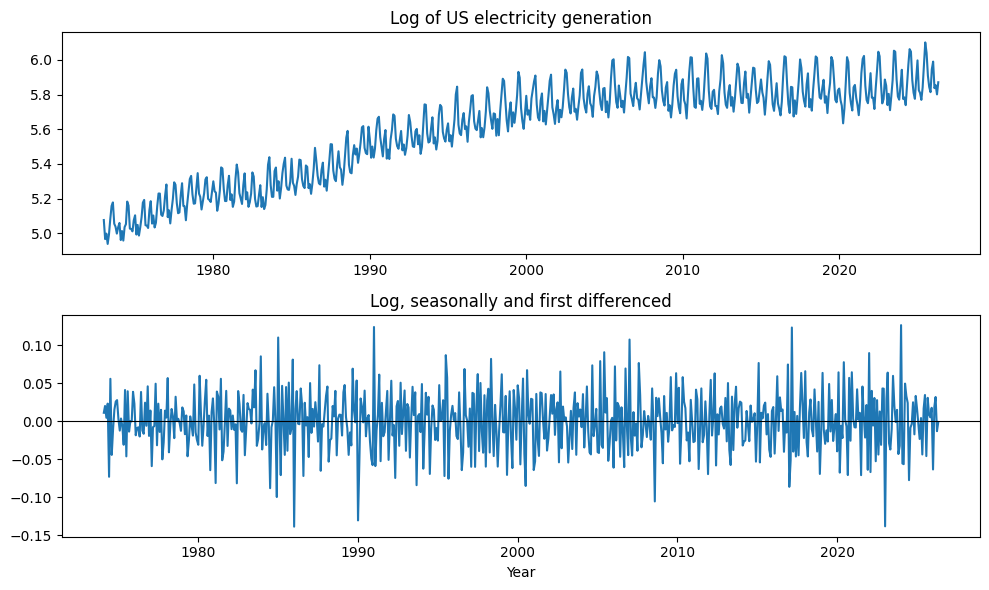

628 1974-02-01 00:00:00


In [10]:
log_y = np.log(y)

# seasonal difference first, then ordinary difference
z = log_y.diff(12).diff(1).dropna()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
axes[0].plot(log_y.index, log_y.values)
axes[0].set_title("Log of US electricity generation")
axes[1].plot(z.index, z.values)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title("Log, seasonally and first differenced")
axes[1].set_xlabel("Year")
plt.tight_layout()
plt.show()

print(len(z), z.index[0])   # lost 13 observations: 641 - 13 = 628, starts Feb 1974

The ADF/KPSS tests show the series is non-stationary, and the ACF shows both trend and yearly seasonality. I apply (1) a log transform to stabilise the growing seasonal amplitude, (2) a seasonal difference at lag 12 to remove the yearly pattern, and (3) a first difference to remove the stochastic trend, giving $z_t = \Delta\Delta_{12}\ln X_t$. The transformed series fluctuates around zero without trend or seasonality and with roughly constant variance, so I believe it is stationary. I verify this formally in question 5.

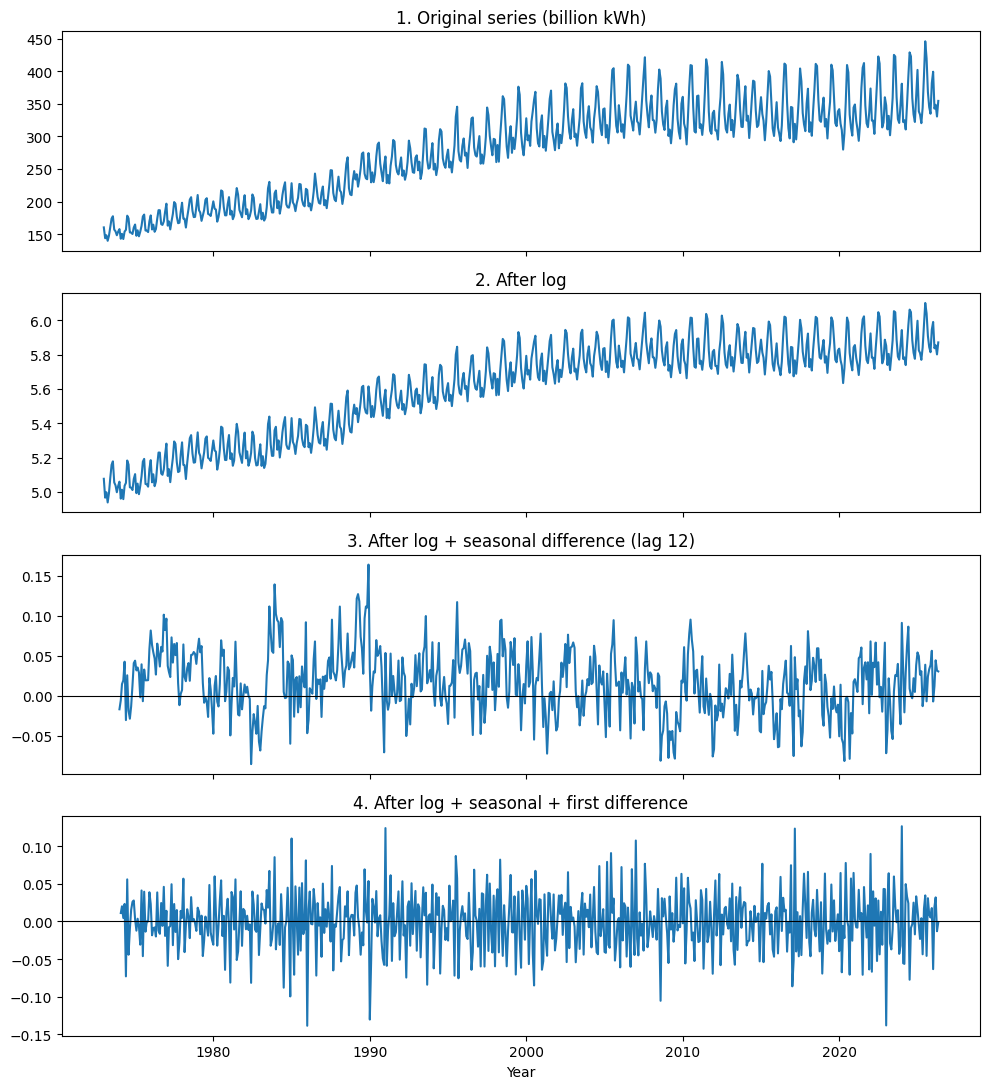

In [11]:
log_y   = np.log(y)
seas_d  = log_y.diff(12).dropna()          # after seasonal difference
z       = log_y.diff(12).diff(1).dropna()  # after seasonal + first difference

stages = [
    (y,      "1. Original series (billion kWh)"),
    (log_y,  "2. After log"),
    (seas_d, "3. After log + seasonal difference (lag 12)"),
    (z,      "4. After log + seasonal + first difference"),
]

fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
for ax, (s, title) in zip(axes, stages):
    ax.plot(s.index, s.values)
    ax.set_title(title)
    if s is seas_d or s is z:
        ax.axhline(0, color='black', linewidth=0.8)
axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.savefig(figs_dir + 'transformation_stages.png', dpi=dpi)
plt.show()

The tests in question 3 and the ACF in question 2 show that the series has a stochastic trend, yearly seasonality, and seasonal swings that grow with the level. I therefore transform the series in three steps, shown in the figure.

**Log transform.** The seasonal amplitude in the original series grows over time. After taking logs the seasonal swings have roughly the same size throughout the sample, so the variance is stabilised.

**Seasonal difference ($s = 12$).** Computing $\ln X_t - \ln X_{t-12}$ compares each month with the same month a year earlier and removes the regular yearly pattern. The series still moves slowly over time (it is higher in the 1970s and 1980s, when growth was fast), so it is not yet centred on a fixed level.

**First difference.** Computing $\Delta$ of the seasonally differenced series removes this remaining slow-moving trend component.

The final transformed series is

$$z_t = \Delta\Delta_{12}\ln X_t = (\ln X_t - \ln X_{t-1}) - (\ln X_{t-12} - \ln X_{t-13}).$$

Is it stationary? I believe so. The series fluctuates around zero, shows no trend and no visible yearly pattern, and its spread looks roughly constant over time. There are a few larger outliers (around $\pm 0.12$ to $\pm 0.14$, e.g. in the mid-1980s, 1990-91 and 2023), but they do not change the overall level or variance. I confirm this formally with ADF and KPSS tests in question 5. The transformation costs 13 observations (12 for the seasonal difference and 1 for the first difference), so the sample starts in February 1974.

## 5. Validate the Stationarity of the Transformed Time Series
In the cell below you are expected to validate the stationarity of the transformed time series using the ADF and KPSS tests. What do you conclude from the ADF and KPSS tests? Is the transformed time series stationary? Explain your reasoning for the chosen specification of the tests.

In [12]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

def run_tests(series, reg):
    adf = adfuller(series, regression=reg, autolag="AIC")
    kpss_test = kpss(series, regression= reg, nlags= "auto")
    print(f"---regression = '{reg}' ---")
    print(f"ADF : stat = {adf[0]:.3f}, p = {adf[1]:.4f}, lags used = {adf[2]}, 5% crit = {adf[4]['5%']:.3f}")
    print(f"KPSS: stat = {kpss_test[0]:.3f},  p = {kpss_test[1]:.4f}, lags = {kpss_test[2]}, 5% crit = {kpss_test[3]['5%']:.3f}")

run_tests(z, 'ct') #robustness check
run_tests(z, 'c') #main specification

---regression = 'ct' ---
ADF : stat = -9.505, p = 0.0000, lags used = 18, 5% crit = -3.418
KPSS: stat = 0.046,  p = 0.1000, lags = 45, 5% crit = 0.146
---regression = 'c' ---
ADF : stat = -9.512, p = 0.0000, lags used = 18, 5% crit = -2.866
KPSS: stat = 0.048,  p = 0.1000, lags = 45, 5% crit = 0.463


**Specification.**

After the log, seasonal and first differences, the series fluctuates around a fixed level near zero with no visible trend. My main specification therefore includes only a constant ('c'), so that the alternative hypothesis is stationarity around a constant mean. Including a trend term would test for a deterministic trend that the plot does not show. As a robustness check I also use a constant and trend ('ct'). ADF lag length is chosen by AIC (18 lags) and the KPSS bandwidth automatically.

**Results.**

The ADF test (H0: unit root) gives a statistic of $-9.51$ with a 5% critical value of $-2.87$ ($p < 0.01$), so the unit root is rejected. The KPSS test (H0: stationarity) gives $0.048$ with a 5% critical value of $0.463$ ($p \ge 0.10$), so stationarity is not rejected. The results are the same with a trend ($-9.51$ vs $-3.42$; $0.046$ vs $0.146$).

**Conclusion.**

Both tests, whose null hypotheses are opposite, agree that the transformed series is stationary. This contrasts with the original series, where ADF failed to reject the unit root and KPSS rejected stationarity. The transformation has therefore achieved its purpose, and the series can be modelled with a stationary seasonal ARMA, i.e. a SARIMA model with $d = 1$, $D = 1$ and $s = 12$.

# PART 2: Baseline Model (15 pts)

## 6. Model Structure

You are asked to plot the autocorrelation function (ACF) and partial autocorrelation function (PACF) of the transformed time series in the cell below. You can set the amount of lags equal 36 (equivalent to 3 years).

What do you observe in the ACF and PACF plots? What kind of dynamics are present in the time series? What kind of model structure would you propose for the time series? Explain your reasoning.

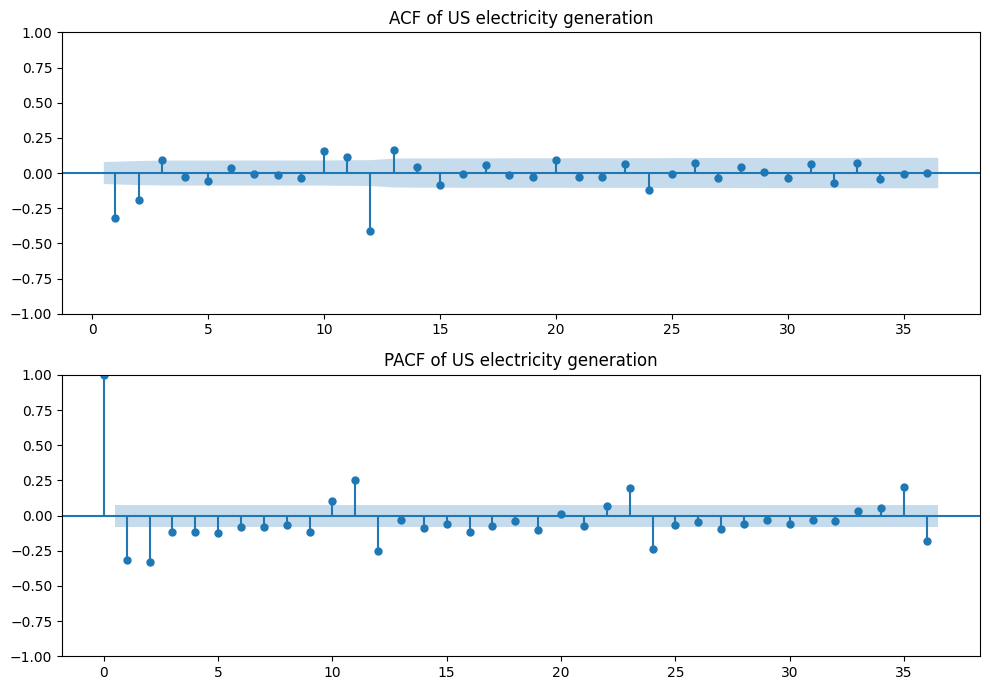

      ACF   PACF  ACF significant  PACF significant
1  -0.317 -0.317             True              True
2  -0.194 -0.327             True              True
3   0.092 -0.116             True              True
4  -0.028 -0.120            False              True
5  -0.054 -0.127            False              True
6   0.033 -0.079            False              True
7  -0.009 -0.080            False              True
8  -0.014 -0.070            False             False
9  -0.037 -0.118            False              True
10  0.160  0.100             True              True
11  0.111  0.256             True              True
12 -0.410 -0.251             True              True
13  0.165 -0.034             True             False
14  0.045 -0.088            False              True
15 -0.081 -0.062             True             False
16 -0.004 -0.115            False              True
17  0.055 -0.071            False             False
18 -0.016 -0.037            False             False
19 -0.030 -0

In [13]:
fig, axes = plt.subplots(2,1, figsize=(10,7))
plot_acf(z, lags=36, ax=axes[0], zero=False)
plot_pacf(z, lags=36, ax=axes[1], method='ywm')
axes[0].set_title("ACF of US electricity generation")
axes[1].set_title("PACF of US electricity generation")
plt.tight_layout()
plt.show()

#exact values

acf_z = acf(z, nlags=36)
pacf_z = pacf(z, nlags=36, method='ywm')
band=1.96/np.sqrt(len(z))
tab = pd.DataFrame({"ACF": acf_z, "PACF": pacf_z})
tab['ACF significant'] = tab['ACF'].abs() > band
tab['PACF significant'] = tab['PACF'].abs() >band
print(tab.iloc[1:].round(3))
print("band:", round(band, 3))

**Observations.** The ACF of the transformed series has significant negative spikes at lags 1 and 2 ($-0.32$ and $-0.19$) and is within the confidence band at lags 4 to 9, so it cuts off after lag 2. The PACF has no sharp cutoff: it is significant at lags 1 and 2 ($-0.32$, $-0.33$) and then decays gradually, staying slightly negative. At the seasonal lags the ACF has a large negative spike at lag 12 ($-0.41$), a small one at lag 24 ($-0.12$), and is insignificant at lag 36, so it cuts off after the first seasonal lag. The PACF at the seasonal lags tails off ($-0.25$, $-0.23$, $-0.18$ at lags 12, 24, 36). The ACF at lags 11 and 13 ($0.11$, $0.17$) is close to $\rho_1\rho_{12} \approx 0.13$, which is consistent with a multiplicative seasonal structure.

**Dynamics.** After the log, seasonal and first difference, the series is stationary, but it still has short-run dependence on shocks of the previous one to two months, plus a yearly seasonal dependence at lag 12. The negative autocorrelations at lags 1 and 12 are typical after differencing.

**Proposed model structure.** A cutoff in the ACF together with a gradually decaying PACF points to moving-average terms. The non-seasonal part therefore has $q = 2$ and $p = 0$, and the seasonal part has $Q = 1$ and $P = 0$. Together with the differencing from question 4 ($d = 1$, $D = 1$, $s = 12$) this gives

$$\text{SARIMA}(0,1,2)(0,1,1)_{12}$$

estimated on the log of the series. A pure AR model would need many terms because the PACF does not cut off, so MA terms describe the pattern more parsimoniously. A simpler alternative is $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ (the "airline model"); the significant lag-2 spike motivates the extra MA term, and I check this choice with the residual diagnostics in the next question.

## 7. Model Estimation

In the cell below you are expected to estimate the model structure you proposed in the previous question. You can use the `ARIMA` and/or `SARIMAX` method from the `statsmodels` library to estimate the model.

Once you have estimated your model, print the summary of the model. How do you interpret the model coefficients? Are they statistically significant? Comment on the fit of the model based on residual diagnostics.

                                      SARIMAX Results                                       
Dep. Variable:                                Value   No. Observations:                  641
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                1384.373
Date:                              Wed, 07 Oct 2026   AIC                          -2760.746
Time:                                      15:58:32   BIC                          -2742.976
Sample:                                  01-01-1973   HQIC                         -2753.843
                                       - 05-01-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4766      0.036    -13.113      0.000      -0.548      -0.405
ma.L2         -0.25

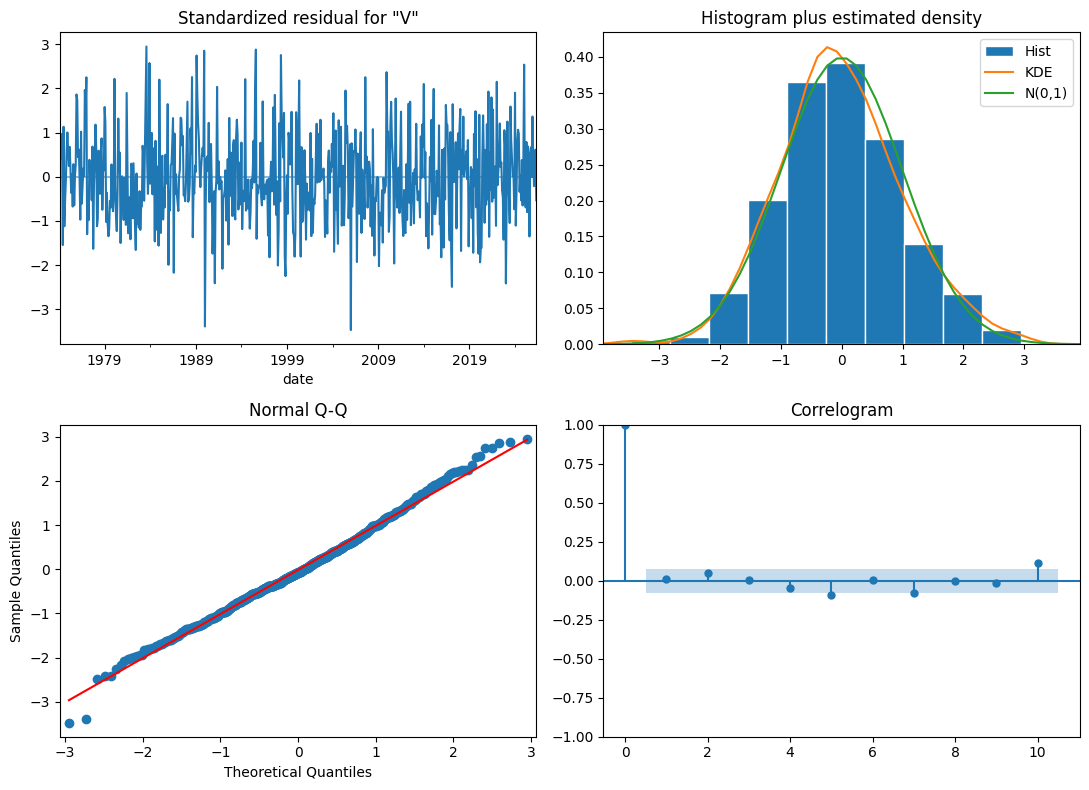

      lb_stat  lb_pvalue
12  25.050667   0.002916
24  53.467633   0.000118
36  62.536836   0.001428


In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings("ignore")

log_y = np.log(y)
model= SARIMAX(log_y, order=(0,1,2), seasonal_order=(0,1,1,12))
res=model.fit(disp=False)
print(res.summary())

#residual diagnostics (skip 13 residuals) , which are distored by the differencing)

resid = res.resid.iloc[13:]

res.plot_diagnostics(figsize=(11,8))
plt.tight_layout()
plt.show()

print(acorr_ljungbox(resid, lags=[12,24,36], model_df=3))

**Coefficients.**

The estimated model is $\text{SARIMA}(0,1,2)(0,1,1)_{12}$ on the log series. All MA coefficients are negative and statistically significant ($p < 0.001$): $\hat\theta_1 = -0.48$, $\hat\theta_2 = -0.25$ and $\hat\Theta_1 = -0.85$, and none of the 95% intervals contains zero. A positive shock is therefore partly reversed in the following one to two months, and the shock of the same month a year earlier is strongly corrected for. The shock standard deviation is about $0.026$ (roughly 2.6% in the level). The seasonal coefficient is fairly close to $-1$, which indicates a very stable yearly pattern.

**Residual diagnostics.**

The residuals fluctuate around zero with constant variance (heteroskedasticity test $p = 0.92$) and are approximately normal (histogram, Q-Q plot, Jarque-Bera $p = 0.12$). However, the Ljung-Box test rejects the null of no autocorrelation at lags 12, 24 and 36 ($p = 0.003$, $0.0001$, $0.001$), and the correlogram shows small significant bars around lags 5, 7 and 10. The model captures the main structure (the large spikes at lags 1, 2 and 12 are gone), but some weak autocorrelation remains, so the fit is good but not perfect and the model can potentially be improved.

# PART 3: Model Selection In-Sample (15 pts)

## 8. Model Selection Based on Information Criteria

In the cell below you are expected to select the best model based on the BIC. Based on your initial guess of the model structure, choose a set of models to estimate.

For your chosen model, report the BIC value and comment on the model fit (using residual diagnostics and appropriate tests). Furthermore, compare your optimal model with the model you estimated in the previous question.

In [15]:
import itertools, warnings
warnings.filterwarnings("ignore")

results = []
for p,q, P, Q in itertools.product(range(3), range(3), range(2), range(2)):
    try:
        m= SARIMAX(log_y, order=(p,1,q), seasonal_order=(P,1,Q,12)).fit(disp=False)
        results.append({'p':p, 'q':q, 'P':P, 'Q':Q, 'AIC':m.aic, 'BIC':m.bic})
    except Exception:
            print("failed:", p,q,P,Q)

bic_table=pd.DataFrame(results).sort_values("BIC").reset_index(drop=True)
print(bic_table.head(10))

   p  q  P  Q          AIC          BIC
0  1  1  0  1 -2763.755266 -2745.985105
1  0  2  0  1 -2760.746323 -2742.976163
2  1  1  1  1 -2763.423755 -2741.211054
3  1  2  0  1 -2761.938127 -2739.725427
4  2  1  0  1 -2761.899732 -2739.687031
5  0  2  1  1 -2760.726794 -2738.514093
6  2  1  1  1 -2761.398840 -2734.743599
7  2  2  0  1 -2759.993370 -2733.338129
8  2  2  1  1 -2759.785457 -2728.687676
9  1  2  1  1 -2751.110180 -2724.454939


                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  641
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                1385.878
Date:                            Wed, 07 Oct 2026   AIC                          -2763.755
Time:                                    18:21:56   BIC                          -2745.985
Sample:                                01-01-1973   HQIC                         -2756.852
                                     - 05-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3806      0.053      7.132      0.000       0.276       0.485
ma.L1         -0.8506      0.032   

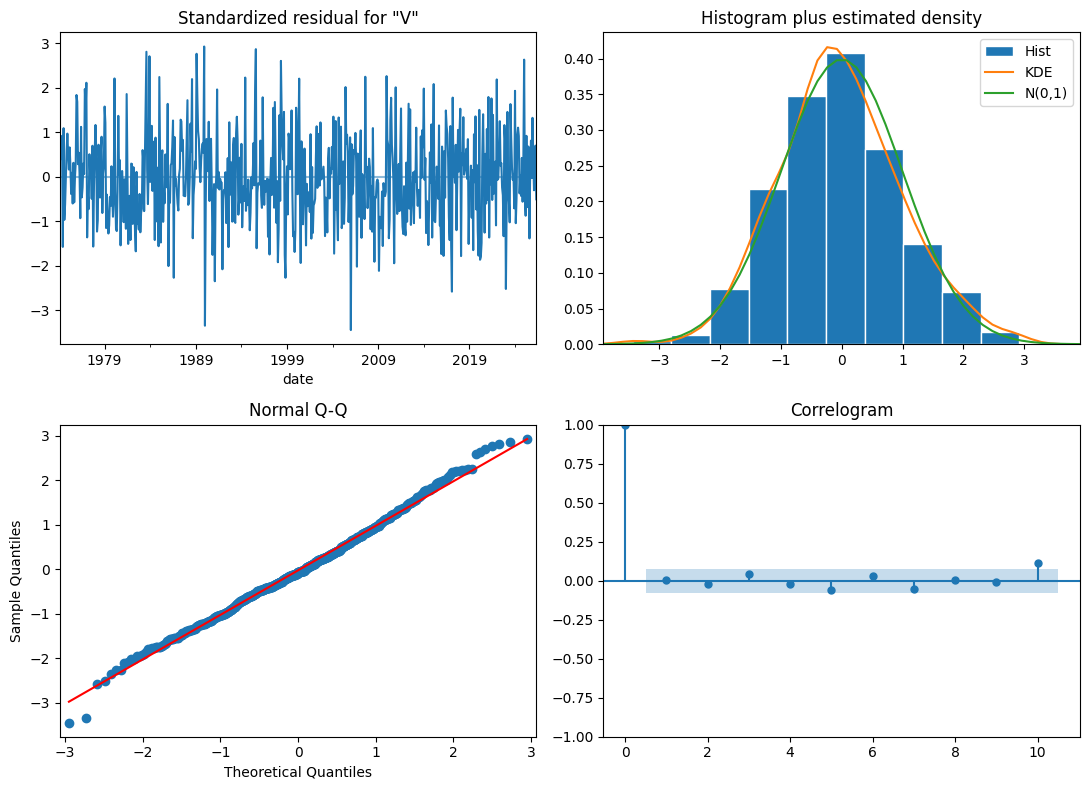

      lb_stat  lb_pvalue
12  18.295788   0.031893
24  46.445577   0.001114
36  55.440940   0.008543


In [44]:
best = bic_table.iloc[0]
p,q, P, Q = int(best.p), int(best.q), int(best.P), int(best.Q)

res_best = SARIMAX(log_y, order=(p,1,q), seasonal_order = (P, 1, Q, 12)).fit(disp=False)
print(res_best.summary())
print("BIC", res_best.bic)
res_best.plot_diagnostics(figsize=(11,8))

plt.tight_layout()
plt.show()

resid = res_best.resid.iloc[13:]
print(acorr_ljungbox(resid, lags=[12,24,36], model_df=p+q+P+Q))

**Search.** I estimated 36 models $\text{SARIMA}(p,1,q)(P,1,Q)_{12}$ on the log series, with $p, q \in \{0,1,2\}$ and $P, Q \in \{0,1\}$, keeping $d = D = 1$ from the stationarity analysis, and selected by BIC.

**Optimal model.** The BIC selects $\text{SARIMA}(1,1,1)(0,1,1)_{12}$ with BIC $= -2745.99$. All coefficients are significant: $\hat\varphi_1 = 0.38$, $\hat\theta_1 = -0.85$, $\hat\Theta_1 = -0.86$ (all $p < 0.001$). The residuals have constant variance (heteroskedasticity test $p = 0.92$) and are consistent with normality (Jarque-Bera $p = 0.16$). The Ljung-Box test is no longer rejected at lag 1 ($p = 0.93$), but it still rejects at lags 12, 24 and 36 ($p = 0.032$, $0.001$, $0.009$), so a small amount of autocorrelation remains.

**Comparison.** The model from the previous question, $\text{SARIMA}(0,1,2)(0,1,1)_{12}$, has BIC $= -2742.98$ and is the second best model. The optimal model has the same number of parameters (four), so the lower BIC (a difference of 3.0) reflects a genuinely better fit. Its Ljung-Box p-values are also higher at all lags (for example $0.032$ vs $0.003$ at lag 12), so its residuals are closer to white noise, although some autocorrelation remains in both. Adding more terms (for example a seasonal AR term) does not lower the BIC, because the penalty outweighs the small gain in fit.

# PART 4: Model Selection Out-of-Sample (20 pts)

## 9. Model Selection Based on Cross-Validation

In the cells below you are expected to select the best models based on time series cross-validation for 1-, 6-, and 12-step ahead forecasts based on the same set of models evaluated above. The initial training set consists of all observations except for the last 10 years (120 observations) of data. You can evaluate the models based on the mean squared error (MSE).

For each of your chosen models report the MSE value. Are your optimal models based on 1-, 6-, and 12-step ahead forecasts different? Compare your optimal models with the optimal model you selected based on the BIC. Do they differ, and, if so, how?

In [29]:
n, n_test = len(log_y), 120          # 641 observations, last 120 are the test period

def cv_forecasts(order, seasonal_order, refit_every=12):
    out = []
    for t in range(n - n_test, n):                   # t = size of the training set
        if (t - (n - n_test)) % refit_every == 0:    # re-estimate every 12 months
            res = SARIMAX(log_y.iloc[:t], order=order,
                          seasonal_order=seasonal_order).fit(disp=False)
        else:                                        # otherwise only add the newest observation
            res = res.extend(log_y.iloc[t - 1:t])
        out.append((t, res.forecast(min(12, n - t))))
    return out

def mse(fc_list, h):
    """MSE of the h-step-ahead forecasts, on the original scale."""
    errors = [y.iloc[t + h - 1] - np.exp(fc.iloc[h - 1]) for t, fc in fc_list if len(fc) >= h]
    return np.mean(np.square(errors))

# the models to compare ( the top 5 from the BIC table)
models = {
    "(1,1,1)(0,1,1)12": ((1, 1, 1), (0, 1, 1, 12)),
    "(0,1,2)(0,1,1)12": ((0, 1, 2), (0, 1, 1, 12)),
    "(1,1,1)(1,1,1)12": ((1, 1, 1), (1, 1, 1, 12)),
    "(1,1,2)(0,1,1)12": ((1, 1, 2), (0, 1, 1, 12)),
    "(2,1,1)(0,1,1)12": ((2, 1, 1), (0, 1, 1, 12)),
}

all_fc = {name: cv_forecasts(o, s) for name, (o, s) in models.items()}

mse_table = pd.DataFrame({h: {name: mse(fc, h) for name, fc in all_fc.items()}
                          for h in [1, 6, 12]})
print(mse_table.round(2))
print(mse_table.idxmin())            # best model for each horizon

                     1       6       12
(1,1,1)(0,1,1)12  90.12  107.54  134.98
(0,1,2)(0,1,1)12  91.07  107.67  139.24
(1,1,1)(1,1,1)12  90.59  107.80  135.66
(1,1,2)(0,1,1)12  91.74  108.23  138.37
(2,1,1)(0,1,1)12  90.70  108.17  137.26
1     (1,1,1)(0,1,1)12
6     (1,1,1)(0,1,1)12
12    (1,1,1)(0,1,1)12
dtype: object


I evaluated the five models with the lowest BIC using expanding-window cross-validation, with the last 120 observations (June 2016 to May 2026) as test period, and compared the mean squared errors (on the original scale, in billion kWh squared). The parameters were re-estimated every 12 months; between re-estimations the model was updated with the new observations without re-fitting.

| Model | 1-step | 6-step | 12-step |
|---|---|---|---|
| (1,1,1)(0,1,1)$_{12}$ | 90.12 | 107.54 | 134.98 |
| (0,1,2)(0,1,1)$_{12}$ | 91.07 | 107.67 | 139.24 |
| (1,1,1)(1,1,1)$_{12}$ | 90.59 | 107.80 | 135.66 |
| (1,1,2)(0,1,1)$_{12}$ | 91.74 | 108.23 | 138.37 |
| (2,1,1)(0,1,1)$_{12}$ | 90.70 | 108.17 | 137.26 |

The MSE increases with the horizon for all models, as forecasting further ahead is harder. The optimal model is the same for all three horizons, $\text{SARIMA}(1,1,1)(0,1,1)_{12}$, and it is also the model selected by the BIC, so the in-sample and out-of-sample criteria agree. The differences between the models are small, particularly for the 1- and 6-step horizons (under 2% and 1%), so the ranking should not be over-interpreted. The largest difference is at 12 steps, where the model from question 7, $(0,1,2)(0,1,1)_{12}$, performs worst. Adding a seasonal AR term does not improve forecasts.

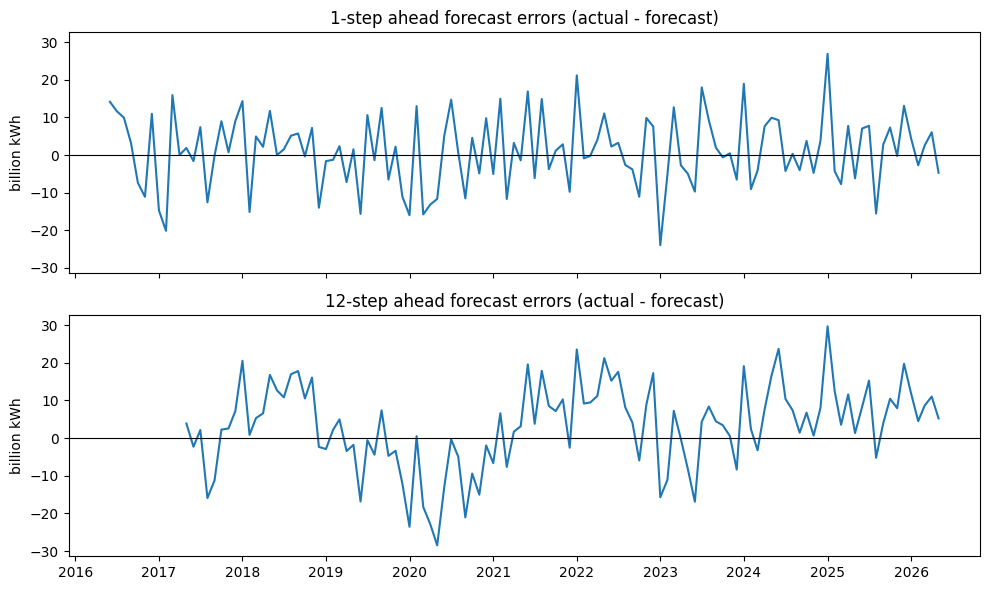

In [33]:
best = "(1,1,1)(0,1,1)12"
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)
for ax, h in zip(axes, [1, 12]):
    err = pd.Series({y.index[t + h - 1]: y.iloc[t + h - 1] - np.exp(f.iloc[h - 1])
                     for t, f in all_fc[best] if len(f) >= h})
    ax.plot(err.index, err.values)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{h}-step ahead forecast errors (actual - forecast)")
    ax.set_ylabel("billion kWh")
plt.tight_layout()
plt.show()

The 1-step forecast errors fluctuate around zero without long runs of the same sign, while the 12-step errors are larger and persistent: the model under-forecasts in 2018 and from 2021 onwards and over-forecasts around 2020, as it cannot anticipate medium-term shifts in the level such as the 2020 drop and the recent increase in generation.

# PART 5: Benchmarking (25 pts)

## 10. Model Comparison Against a Naive Benchmark

In the cell below you are expected to compare the forecasts of your optimal models based on time series cross-validation against forecasts of a naive benchmark using the same time series cross-validation setup as explained above. Note that this implies that you can use the results (forecasts) from the cross-validation exercise above. In other words, there is no need you do to redo the forecasts for the test sets using your optimal models.

The naïve benchmark forecasts the US total energy generation using the seasonal naïve method with drift

$$\hat{X}_{t}(h) = X_{t+h-s(k+1)} + h \frac{X_{t} - X_{1}}{t - 1}$$

where $X_{t}$ is the US total energy generation at time $t$, $s$ is the seasonal period, and $k$ is the integer part of $(h - 1)/s$ (i.e. the number of complete years in the forecast period prior to time $t + h$). This sounds complicated, but it merely means that for example, with monthly data, the forecast for all future February values is equal to the last observed February value. The second component of the forecast is the drift, which is the average change seen in the time series up to time $t$ and extrapolated to time $t + h$.

Plot the $h$-step ahead forecasts from your $h$-step ahead cross-validated model together with the corresponding naive benchmark $h$-step ahead forecasts and the actual US total energy generation. Comment on the forecast performance of your optimal models compared to the naive benchmark. Perform a Diebold-Mariano test to test whether the differences in the forecasting performance for the different horizons are statistically significant. Which model would you recommend for forecasting the US total energy generation?

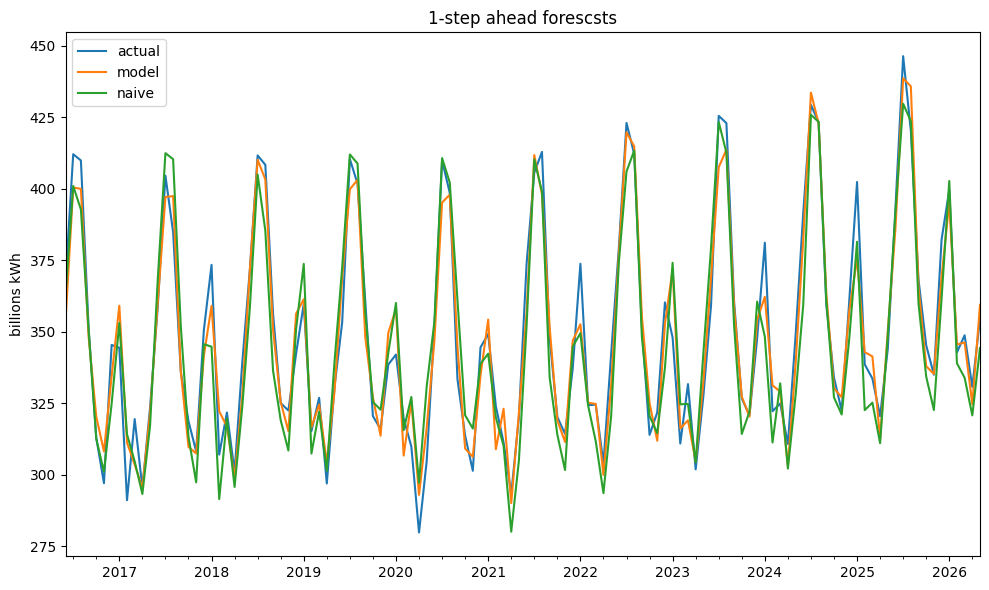

   MSE model  MSE naive  DM stat  p-value
h                                        
1     90.115    172.696   -4.662      0.0


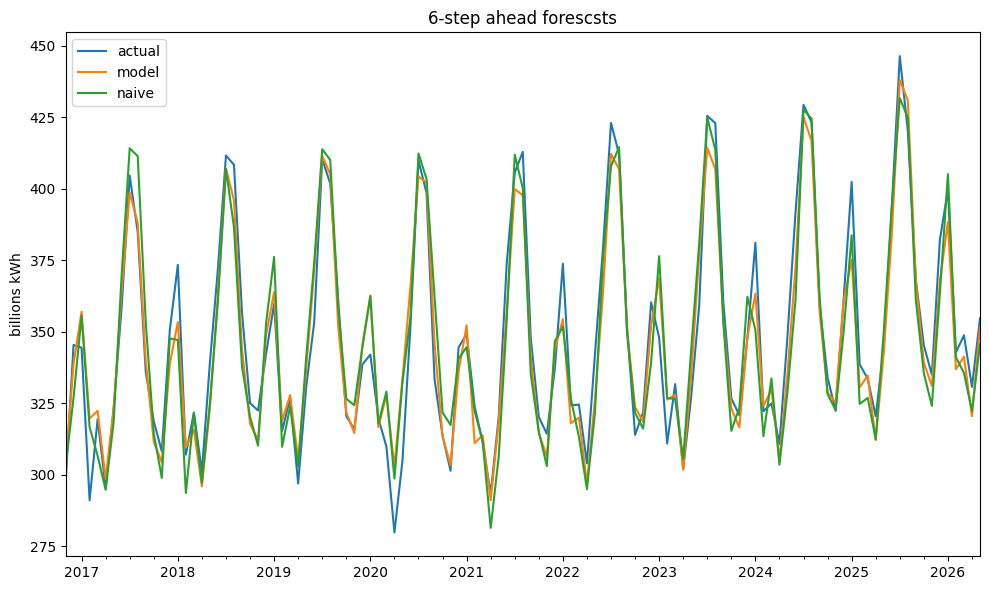

   MSE model  MSE naive  DM stat  p-value
h                                        
1     90.115    172.696   -4.662      0.0
6    107.536    168.337   -4.138      0.0


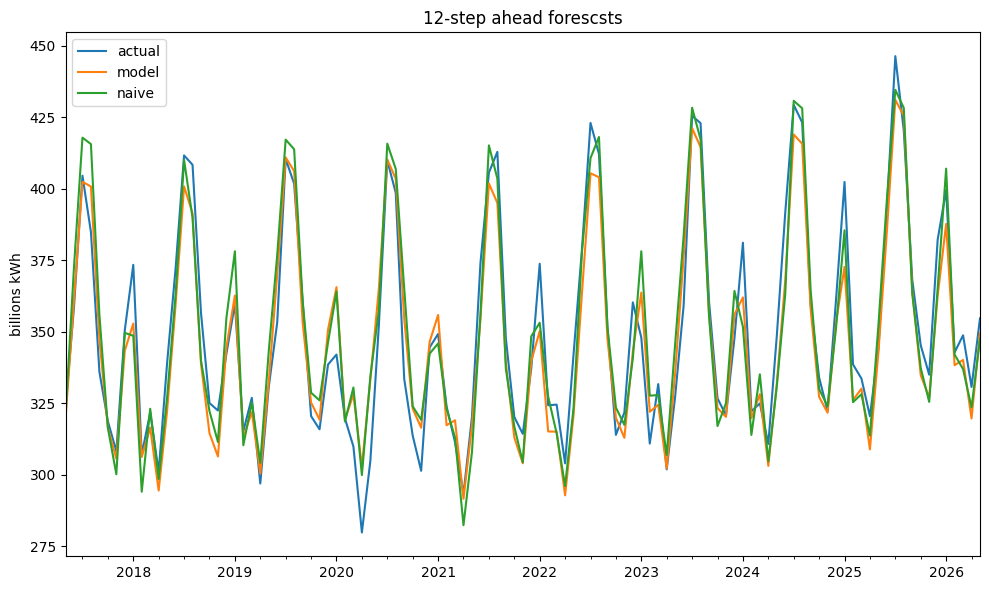

    MSE model  MSE naive  DM stat  p-value
h                                         
1      90.115    172.696   -4.662    0.000
6     107.536    168.337   -4.138    0.000
12    134.980    168.071   -1.574    0.115


In [49]:
import statsmodels.api as sm

best = "(1,1,1)(0,1,1)12"
i=np.arange(len(y))
summary = []

for h in [1, 6, 12]:
    #model forecasts for horizon h (original scale)
    model= pd.Series({y.index[t+h-1]: np.exp(f.iloc[h-1])
    for t,f in all_fc[best] if len(f) >= h})

    #naive: value 12 maonths before the target + h* average change so far
    naive= (y.shift(12) + h * (y.shift(h) - y.iloc[0]) / (i-h)).loc[model.index]

    df = pd.DataFrame({"actual": y.loc[model.index], "model": model, "naive": naive})
    df.plot(figsize=(10, 6), title=f"{h}-step ahead forescsts", ylabel="billions kWh")
    plt.tight_layout()
    plt.show()

    #mse of both, and the Diebold-Mariano test
    mse_h = (df[["model", "naive"]].sub(df["actual"], axis=0) ** 2).mean()
    d = ((df["actual"] - df["model"]) ** 2 - (df["actual"] - df["naive"]) ** 2).values
    dm = sm.OLS(d, np.ones(len(d))).fit(cov_type="HAC", cov_kwds={"maxlags": h -1})
    summary.append({"h": h, "MSE model": mse_h["model"], "MSE naive": mse_h["naive"],
                    "DM stat": dm.tvalues[0], "p-value": dm.pvalues[0]})


    results= pd.DataFrame(summary).set_index("h").round(3)
    print(results)

Both forecasts follow the strong seasonal cycle well at all horizons. The SARIMA forecast tracks the actual series more closely, especially in the summer peaks. At h = 12 the naive forecast tends to overshoot the peaks, because it copies last year's value and adds the drift. Both methods miss sudden deviations from the seasonal pattern, such as the sharp dip in spring 2020 and the winter spikes, since these are unpredictable from past data. The model's forecasts get slightly less accurate as the horizon increases.

**Diebold-Mariano**

The SARIMA(1,1,1)(0,1,1)₁₂ model has a lower MSE than the seasonal naive forecast with drift at all three horizons (90.1 vs 172.7 at h = 1, 107.5 vs 168.3 at h = 6, 135.0 vs 168.1 at h = 12). The Diebold-Mariano test (H₀: equal expected squared error, HAC standard errors with h−1 lags) rejects H₀ at the 5% level for h = 1 (DM = −4.66, p < 0.001) and h = 6 (DM = −4.14, p < 0.001), so the model is significantly more accurate over short and medium horizons. At h = 12 the improvement is smaller (about 20%) and not significant (DM = −1.57, p = 0.115). I therefore recommend the SARIMA model for forecasting up to about half a year ahead. At 12 months it is still better on average, but the evidence is weaker, and the simple naive forecast is a reasonable alternative. The test sample is small (120 months), so the h = 12 test may also have low power.